# DeepLearning

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.datasets as datasets

In [33]:
import os

# 1. 현재 노트북 파일이 있는 위치를 가져옵니다. (src/models/xgboost)
current_dir = os.getcwd()

# 2. 세 단계 위로 올라가서 프로젝트 루트를 잡습니다.
# xgboost -> models(1) -> src(2) -> Root(3)
BASE_DIR = os.path.abspath(os.path.join(current_dir, "../../.."))

# 확인용: 출력된 경로에 data 폴더가 있어야 합니다.
print(f"현재 프로젝트 루트: {BASE_DIR}")

# 3. 경로 결합
X_path = os.path.join(BASE_DIR, 'data', 'preprocessed', 'cell2cell_train.csv')
y_path = os.path.join(BASE_DIR, 'data', 'preprocessed', 'cell2cell_train_churn.csv')

# 4. 파일 읽기
X = pd.read_csv(X_path)
y = pd.read_csv(y_path)

print("데이터 로드 성공!")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

현재 프로젝트 루트: /Users/kimunoo/SKN24/Project/Main_Project/SKN24-2nd-6Team
데이터 로드 성공!


In [34]:
# 데이터 개수 확인
print(X.shape, y.shape, X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print(y.sum())

(49776, 65) (49776, 1) (39820, 65) (39820, 1) (9956, 65) (9956, 1)
Churn    14257
dtype: int64


# 배치 사이즈 64

In [35]:
from torch.utils.data import DataLoader, TensorDataset

# 1. 데이터를 PyTorch 텐서로 변환 (float32 타입 권장)
# y_train이 DataFrame이라면 .values를 써서 numpy로 바꾼 뒤 변환해야 합니다.
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.LongTensor(y_train.values.flatten()) # 분류 문제는 LongTensor

X_val_tensor = torch.FloatTensor(X_test.values) # 아까 분리한 test 세트를 검증용으로 사용
y_val_tensor = torch.LongTensor(y_test.values.flatten())

# 2. Dataset 생성 (입력과 타겟을 하나로 묶음)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# 3. DataLoader 생성 (이게 있어야 train_integrated 함수가 돌아갑니다!)
batch_size = 64 # 한 번에 학습할 데이터 양

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("DataLoader 준비 완료!")

DataLoader 준비 완료!


### 딥러닝 구조 생성

In [36]:
class RobustNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.2, use_bn=True):
        super().__init__()
        
        layers = [nn.Flatten()]
        current_size = input_size
        
        # 은닉층 동적 생성 (리스트 형태로 넣으면 자동으로 층을 쌓음)
        for h_size in hidden_sizes:
            layers.append(nn.Linear(current_size, h_size))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            current_size = h_size
            
        # 출력층
        layers.append(nn.Linear(current_size, num_classes))
        
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [37]:
# 조기 종료
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience     # 성능 개선이 없을 때 기다릴 횟수
        self.min_delta = min_delta   # 이 정도는 개선되어야 개선으로 인정
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [38]:
def train_integrated(model, criterion, optimizer, scheduler, train_loader, val_loader, 
                     epochs=50, early_stopping=None):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- 학습 단계 ---
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # --- 검증 단계 ---
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / len(val_loader.dataset) # 주신 코드의 val_data를 val_loader.dataset으로 수정
        
        # 기록
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f}")
        
        # --- 스케줄러 및 조기종료 ---
        scheduler.step(avg_val_loss) # 성능 기반 스케줄러(ReduceLROnPlateau 등) 기준
        
        if early_stopping and early_stopping(avg_val_loss):
            print("Early Stopping Triggered!")
            break
            
    return history

### 실행 코드

In [39]:
# 하이퍼파라미터 설정
INPUT_SIZE = X_train.shape[1] # 통신사 데이터 피처 수
HIDDEN_SIZES = [128, 64]      # 은닉층 구조
NUM_CLASSES = 2               # 이탈(1) vs 유지(0)
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4           # L2 규제(가중치 감쇠) 강도 ⭐

# 객체 생성
model = RobustNN(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 검증 손실이 정체될 때 학습률을 자동으로 낮춰주는 스케줄러
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
es = EarlyStopping(patience=7)

# 학습 시작
history = train_integrated(model, criterion, optimizer, scheduler, train_loader, val_loader, early_stopping=es)

Epoch 1/50 | Train Loss: 0.5936 | Val Loss: 0.5809 | Acc: 0.7127
Epoch 2/50 | Train Loss: 0.5811 | Val Loss: 0.5796 | Acc: 0.7138
Epoch 3/50 | Train Loss: 0.5785 | Val Loss: 0.5789 | Acc: 0.7127
Epoch 4/50 | Train Loss: 0.5759 | Val Loss: 0.5776 | Acc: 0.7143
Epoch 5/50 | Train Loss: 0.5726 | Val Loss: 0.5763 | Acc: 0.7143
Epoch 6/50 | Train Loss: 0.5712 | Val Loss: 0.5760 | Acc: 0.7156
Epoch 7/50 | Train Loss: 0.5701 | Val Loss: 0.5762 | Acc: 0.7138
Epoch 8/50 | Train Loss: 0.5682 | Val Loss: 0.5732 | Acc: 0.7150
Epoch 9/50 | Train Loss: 0.5666 | Val Loss: 0.5723 | Acc: 0.7173
Epoch 10/50 | Train Loss: 0.5650 | Val Loss: 0.5736 | Acc: 0.7168
Epoch 11/50 | Train Loss: 0.5651 | Val Loss: 0.5734 | Acc: 0.7134
Epoch 12/50 | Train Loss: 0.5631 | Val Loss: 0.5715 | Acc: 0.7162
Epoch 13/50 | Train Loss: 0.5620 | Val Loss: 0.5743 | Acc: 0.7147
Epoch 14/50 | Train Loss: 0.5612 | Val Loss: 0.5722 | Acc: 0.7157
Epoch 15/50 | Train Loss: 0.5595 | Val Loss: 0.5740 | Acc: 0.7156
Epoch 16/50 | Train

### 평가

In [40]:
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        
        # 1. 확률값 계산 (Softmax)
        probs = torch.softmax(outputs, dim=1)
        
        # 2. '이탈(1)'에 해당하는 확률만 추출
        # .detach().cpu().numpy()를 사용해 완전히 넘파이 배열로 변환합니다.
        pos_probs = probs[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()
        
        # 3. 리스트에 추가 (배열 통째로 추가)
        all_probs.append(pos_probs)
        all_preds.append(preds)
        all_labels.append(labs)

# 4. 리스트에 담긴 여러 배열을 하나의 1차원 넘파이 배열로 합칩니다 (핵심!)
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# 이제 모든 데이터가 깔끔한 1차원 (19912,) 모양이 됩니다.
print(f"최종 데이터 모양: {all_probs.shape}") 



최종 데이터 모양: (9956,)


### 정확도

In [41]:
def get_scores(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 1. Train Score (훈련 데이터 정확도)
train_score = get_scores(model, train_loader)

# 2. Test Score (검증 데이터 정확도)
test_score = get_scores(model, val_loader)

print(f"Train Score (Accuracy): {train_score:.4f}")
print(f"Test Score  (Accuracy): {test_score:.4f}")

Train Score (Accuracy): 0.7322
Test Score  (Accuracy): 0.7168


### Permutation Importance (치환 중요도)

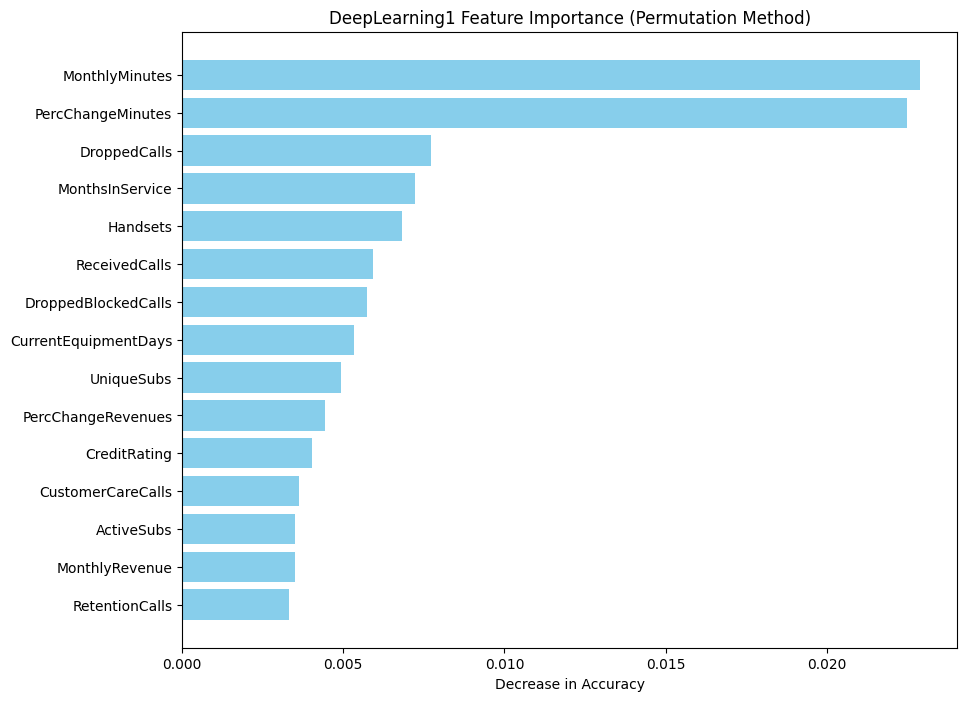

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(model, X_tensor, y_tensor, feature_names):
    model.eval()
    
    # 1. 원본 데이터로 기준 성능(Accuracy) 계산
    with torch.no_grad():
        outputs = model(X_tensor)
        base_acc = (outputs.argmax(dim=1) == y_tensor).float().mean().item()
    
    importances = []
    
    # 2. 각 피처를 하나씩 섞어보며 성능 변화 관찰
    for i in range(X_tensor.shape[1]):
        temp_X = X_tensor.clone()
        
        # i번째 컬럼의 데이터만 무작위로 섞기 (Permutation)
        perm_idx = torch.randperm(temp_X.size(0))
        temp_X[:, i] = temp_X[perm_idx, i]
        
        with torch.no_grad():
            shuffled_out = model(temp_X)
            shuffled_acc = (shuffled_out.argmax(dim=1) == y_tensor).float().mean().item()
        
        # 성능이 얼마나 감소했는지 기록
        importances.append(base_acc - shuffled_acc)
    
    # 3. 결과 시각화
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values(by='importance', ascending=False).head(15) # 상위 15개

    plt.figure(figsize=(10, 8))
    plt.barh(fi_df['feature'], fi_df['importance'], color='skyblue')
    plt.gca().invert_yaxis() # 높은 중요도가 위로 오게
    plt.title("DeepLearning1 Feature Importance (Permutation Method)")
    plt.xlabel("Decrease in Accuracy")
    plt.show()

# 실행 (X_val_tensor와 원본 X의 컬럼명을 넣어주세요)
plot_feature_importance(model, X_val_tensor, y_val_tensor, X.columns)

### Confusion Matrix

In [43]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import torch

# 1. 모델을 평가 모드로 전환
model.eval()

all_preds = []
all_labels = []

# 2. 검증 데이터를 통해 예측값 모으기
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        # 가장 높은 확률을 가진 인덱스를 예측값으로 선택
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 정확도(Accuracy) 계산
acc = accuracy_score(all_labels, all_preds)

print("              Classification Report")

# 클래스 이름을 명시하면 더 보기 좋습니다 (0: 유지, 1: 이탈)
print(classification_report(all_labels, all_preds, target_names=['Stay (0)', 'Churn (1)']))

              Classification Report
              precision    recall  f1-score   support

    Stay (0)       0.73      0.96      0.83      7112
   Churn (1)       0.52      0.10      0.16      2844

    accuracy                           0.72      9956
   macro avg       0.63      0.53      0.50      9956
weighted avg       0.67      0.72      0.64      9956



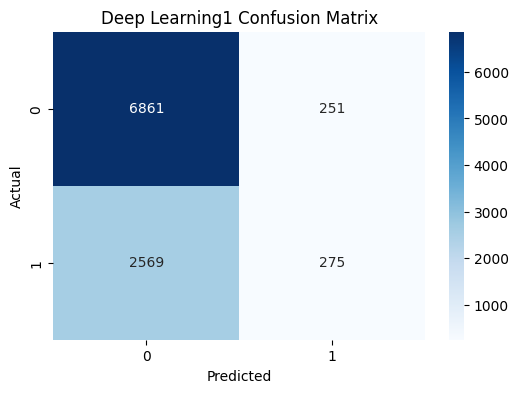

In [44]:
# 5. Confusion Matrix 출력
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Deep Learning1 Confusion Matrix')
plt.show()



### ROC/AUC

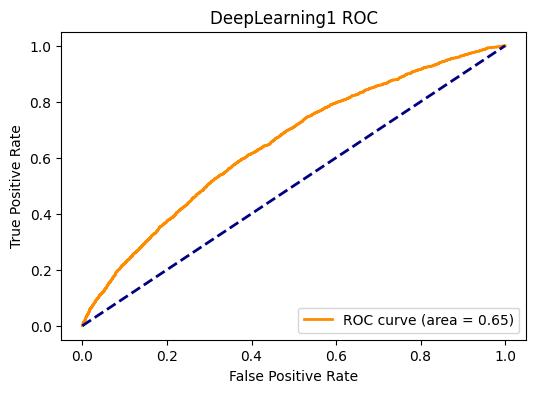

In [45]:
# 6. ROC-AUC 계산
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DeepLearning1 ROC')
plt.legend(loc="lower right")
plt.show()

# 배치 사이즈 16

In [46]:
from torch.utils.data import DataLoader, TensorDataset

# 1. 데이터를 PyTorch 텐서로 변환 (float32 타입 권장)
# y_train이 DataFrame이라면 .values를 써서 numpy로 바꾼 뒤 변환해야 합니다.
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.LongTensor(y_train.values.flatten()) # 분류 문제는 LongTensor

X_val_tensor = torch.FloatTensor(X_test.values) # 아까 분리한 test 세트를 검증용으로 사용
y_val_tensor = torch.LongTensor(y_test.values.flatten())

# 2. Dataset 생성 (입력과 타겟을 하나로 묶음)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# 3. DataLoader 생성 (이게 있어야 train_integrated 함수가 돌아갑니다!)
batch_size = 16 # 한 번에 학습할 데이터 양

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print("DataLoader 준비 완료!")

DataLoader 준비 완료!


### 딥러닝 구조 생성

In [47]:
class RobustNN(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.2, use_bn=True):
        super().__init__()
        
        layers = [nn.Flatten()]
        current_size = input_size
        
        # 은닉층 동적 생성 (리스트 형태로 넣으면 자동으로 층을 쌓음)
        for h_size in hidden_sizes:
            layers.append(nn.Linear(current_size, h_size))
            if use_bn:
                layers.append(nn.BatchNorm1d(h_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            current_size = h_size
            
        # 출력층
        layers.append(nn.Linear(current_size, num_classes))
        
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [48]:
# 조기 종료
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience     # 성능 개선이 없을 때 기다릴 횟수
        self.min_delta = min_delta   # 이 정도는 개선되어야 개선으로 인정
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [49]:
def train_integrated(model, criterion, optimizer, scheduler, train_loader, val_loader, 
                     epochs=50, early_stopping=None):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        # --- 학습 단계 ---
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # --- 검증 단계 ---
        model.eval()
        val_loss = 0
        correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / len(val_loader.dataset) # 주신 코드의 val_data를 val_loader.dataset으로 수정
        
        # 기록
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f}")
        
        # --- 스케줄러 및 조기종료 ---
        scheduler.step(avg_val_loss) # 성능 기반 스케줄러(ReduceLROnPlateau 등) 기준
        
        if early_stopping and early_stopping(avg_val_loss):
            print("Early Stopping Triggered!")
            break
            
    return history

### 실행 코드

In [50]:
# 하이퍼파라미터 설정
INPUT_SIZE = X_train.shape[1] # 통신사 데이터 피처 수
HIDDEN_SIZES = [128, 64]      # 은닉층 구조
NUM_CLASSES = 2               # 이탈(1) vs 유지(0)
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4           # L2 규제(가중치 감쇠) 강도 ⭐

# 객체 생성
model = RobustNN(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 검증 손실이 정체될 때 학습률을 자동으로 낮춰주는 스케줄러
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
es = EarlyStopping(patience=7)

# 학습 시작
history = train_integrated(model, criterion, optimizer, scheduler, train_loader, val_loader, early_stopping=es)

Epoch 1/50 | Train Loss: 0.5919 | Val Loss: 0.5828 | Acc: 0.7107
Epoch 2/50 | Train Loss: 0.5842 | Val Loss: 0.5811 | Acc: 0.7131
Epoch 3/50 | Train Loss: 0.5820 | Val Loss: 0.5813 | Acc: 0.7131
Epoch 4/50 | Train Loss: 0.5794 | Val Loss: 0.5798 | Acc: 0.7144
Epoch 5/50 | Train Loss: 0.5787 | Val Loss: 0.5786 | Acc: 0.7147
Epoch 6/50 | Train Loss: 0.5776 | Val Loss: 0.5768 | Acc: 0.7150
Epoch 7/50 | Train Loss: 0.5758 | Val Loss: 0.5759 | Acc: 0.7156
Epoch 8/50 | Train Loss: 0.5739 | Val Loss: 0.5757 | Acc: 0.7161
Epoch 9/50 | Train Loss: 0.5744 | Val Loss: 0.5756 | Acc: 0.7163
Epoch 10/50 | Train Loss: 0.5750 | Val Loss: 0.5748 | Acc: 0.7143
Epoch 11/50 | Train Loss: 0.5735 | Val Loss: 0.5765 | Acc: 0.7131
Epoch 12/50 | Train Loss: 0.5744 | Val Loss: 0.5753 | Acc: 0.7142
Epoch 13/50 | Train Loss: 0.5735 | Val Loss: 0.5751 | Acc: 0.7144
Epoch 14/50 | Train Loss: 0.5732 | Val Loss: 0.5759 | Acc: 0.7149
Epoch 15/50 | Train Loss: 0.5685 | Val Loss: 0.5724 | Acc: 0.7153
Epoch 16/50 | Train

### 평가

In [51]:
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        
        # 1. 확률값 계산 (Softmax)
        probs = torch.softmax(outputs, dim=1)
        
        # 2. '이탈(1)'에 해당하는 확률만 추출
        # .detach().cpu().numpy()를 사용해 완전히 넘파이 배열로 변환합니다.
        pos_probs = probs[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()
        
        # 3. 리스트에 추가 (배열 통째로 추가)
        all_probs.append(pos_probs)
        all_preds.append(preds)
        all_labels.append(labs)

# 4. 리스트에 담긴 여러 배열을 하나의 1차원 넘파이 배열로 합칩니다 (핵심!)
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# 이제 모든 데이터가 깔끔한 1차원 (19912,) 모양이 됩니다.
print(f"최종 데이터 모양: {all_probs.shape}") 



최종 데이터 모양: (9956,)


### 정확도

In [52]:
def get_scores(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 1. Train Score (훈련 데이터 정확도)
train_score = get_scores(model, train_loader)

# 2. Test Score (검증 데이터 정확도)
test_score = get_scores(model, val_loader)

print(f"Train Score (Accuracy): {train_score:.4f}")
print(f"Test Score  (Accuracy): {test_score:.4f}")

Train Score (Accuracy): 0.7208
Test Score  (Accuracy): 0.7166


### Permutation Importance (치환 중요도)

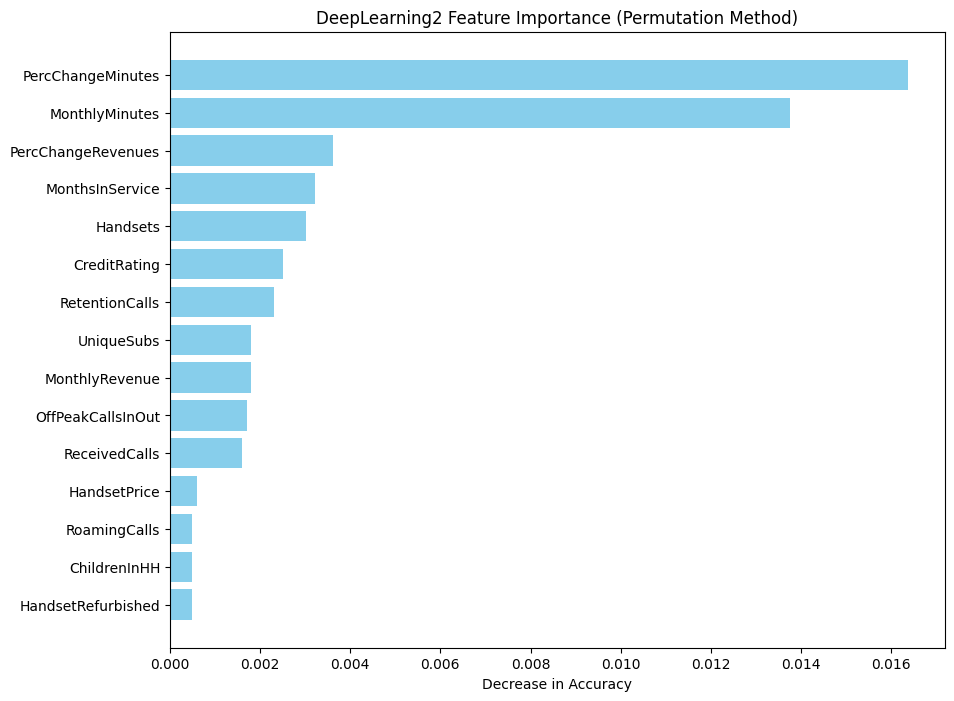

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(model, X_tensor, y_tensor, feature_names):
    model.eval()
    
    # 1. 원본 데이터로 기준 성능(Accuracy) 계산
    with torch.no_grad():
        outputs = model(X_tensor)
        base_acc = (outputs.argmax(dim=1) == y_tensor).float().mean().item()
    
    importances = []
    
    # 2. 각 피처를 하나씩 섞어보며 성능 변화 관찰
    for i in range(X_tensor.shape[1]):
        temp_X = X_tensor.clone()
        
        # i번째 컬럼의 데이터만 무작위로 섞기 (Permutation)
        perm_idx = torch.randperm(temp_X.size(0))
        temp_X[:, i] = temp_X[perm_idx, i]
        
        with torch.no_grad():
            shuffled_out = model(temp_X)
            shuffled_acc = (shuffled_out.argmax(dim=1) == y_tensor).float().mean().item()
        
        # 성능이 얼마나 감소했는지 기록
        importances.append(base_acc - shuffled_acc)
    
    # 3. 결과 시각화
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values(by='importance', ascending=False).head(15) # 상위 15개

    plt.figure(figsize=(10, 8))
    plt.barh(fi_df['feature'], fi_df['importance'], color='skyblue')
    plt.gca().invert_yaxis() # 높은 중요도가 위로 오게
    plt.title("DeepLearning2 Feature Importance (Permutation Method)")
    plt.xlabel("Decrease in Accuracy")
    plt.show()

# 실행 (X_val_tensor와 원본 X의 컬럼명을 넣어주세요)
plot_feature_importance(model, X_val_tensor, y_val_tensor, X.columns)

### Confusion Matrix

In [54]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import torch

# 1. 모델을 평가 모드로 전환
model.eval()

all_preds = []
all_labels = []

# 2. 검증 데이터를 통해 예측값 모으기
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        # 가장 높은 확률을 가진 인덱스를 예측값으로 선택
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 정확도(Accuracy) 계산
acc = accuracy_score(all_labels, all_preds)

print("              Classification Report")

# 클래스 이름을 명시하면 더 보기 좋습니다 (0: 유지, 1: 이탈)
print(classification_report(all_labels, all_preds, target_names=['Stay (0)', 'Churn (1)']))

              Classification Report
              precision    recall  f1-score   support

    Stay (0)       0.72      0.98      0.83      7112
   Churn (1)       0.54      0.05      0.09      2844

    accuracy                           0.72      9956
   macro avg       0.63      0.52      0.46      9956
weighted avg       0.67      0.72      0.62      9956



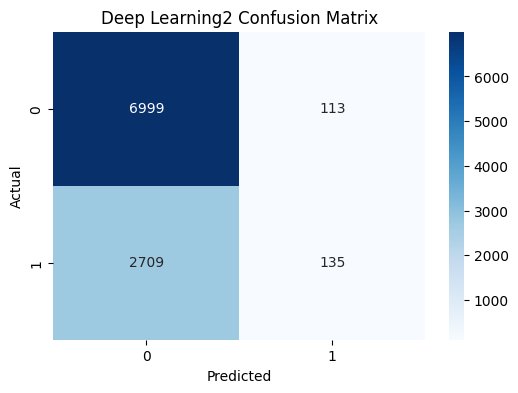

In [ ]:
# 5. Confusion Matrix 출력
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Deep Learning2 Confusion Matrix')
plt.show()



### ROC/AUC

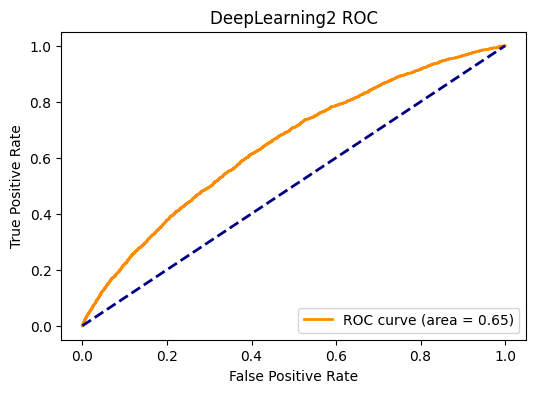

In [56]:
# 6. ROC-AUC 계산
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DeepLearning2 ROC')
plt.legend(loc="lower right")
plt.show()

In [ ]:
import os

# 1. 현재 노트북 파일이 있는 위치를 가져옵니다. (src/models/xgboost)
current_dir = os.getcwd()

# 2. 세 단계 위로 올라가서 프로젝트 루트를 잡습니다.
# xgboost -> models(1) -> src(2) -> Root(3)
BASE_DIR = os.path.abspath(os.path.join(current_dir, "../../.."))


# 3. Optuna

In [79]:
import optuna

def objective(trial):
    from sklearn.metrics import roc_auc_score  # 이 줄이 꼭 필요합니다!
    # 1. 탐색할 하이퍼파라미터 범위 설정
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    hidden_dim = trial.suggest_int("hidden_dim", 32, 256)

    # 2. 새로운 배치 사이즈로 DataLoader 다시 만들기
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # 3. 모델 정의 (탐색 중인 hidden_dim 적용)
    model = RobustNN(INPUT_SIZE, [hidden_dim, hidden_dim//2], 2, dropout_rate=dropout_rate)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # 4. 짧게 학습 (Optuna는 여러 번 돌려야 하므로 epochs를 작게 설정)
    model.train()
    for epoch in range(10):  # 최적값을 찾기 위해 에포크는 5~10회면 충분합니다
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # 5. 검증 데이터로 정확도 측정 (이 점수가 높을수록 좋은 조합)
    # 마지막 평가 부분에서 ROC-AUC 계산
    model.eval()
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            # 2개 노드 중 '이탈(1)'에 해당하는 확률값 추출
            probs = torch.softmax(outputs, dim=1)[:, 1] 
            
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # ROC-AUC 점수 계산
    score = roc_auc_score(all_labels, all_probs)
    
    return score # 이 점수가 높을수록 좋은 조합으로 판단함

In [80]:
# study 객체 생성 (방향은 정확도를 높이는 것이므로 'maximize')
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30) # 30번의 시행착오

print("--- 최적화 결과 ---")
print(f"Best Value (Accuracy): {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-02-23 18:26:16,820] A new study created in memory with name: no-name-b91b700c-1c14-4aa3-af08-e22fa7aafdfc
[I 2026-02-23 18:27:14,795] Trial 0 finished with value: 0.6364740898685132 and parameters: {'lr': 0.000413496236596681, 'batch_size': 16, 'dropout_rate': 0.2692363147370138, 'hidden_dim': 116}. Best is trial 0 with value: 0.6364740898685132.
[I 2026-02-23 18:28:05,090] Trial 1 finished with value: 0.6285862803541962 and parameters: {'lr': 0.01854995500830944, 'batch_size': 16, 'dropout_rate': 0.10098569851394888, 'hidden_dim': 79}. Best is trial 0 with value: 0.6364740898685132.
[I 2026-02-23 18:28:53,683] Trial 2 finished with value: 0.6055447825746465 and parameters: {'lr': 2.140657081620511e-05, 'batch_size': 16, 'dropout_rate': 0.29442246333867617, 'hidden_dim': 58}. Best is trial 0 with value: 0.6364740898685132.
[I 2026-02-23 18:29:06,388] Trial 3 finished with value: 0.6423669450337696 and parameters: {'lr': 0.0015679957934260531, 'batch_size': 128, 'dropout_rate': 

--- 최적화 결과 ---
Best Value (Accuracy): 0.6423669450337696
Best Params: {'lr': 0.0015679957934260531, 'batch_size': 128, 'dropout_rate': 0.30205775483264025, 'hidden_dim': 142}


### 실행 코드

In [81]:
# 1. Optuna가 찾은 최적의 하이퍼파라미터 추출
best = study.best_params

# 2. 하이퍼파라미터 재설정
INPUT_SIZE = X_train.shape[1]
HIDDEN_SIZES = [best['hidden_dim'], best['hidden_dim'] // 2]  # 찾은 hidden_dim 적용
NUM_CLASSES = 2
LEARNING_RATE = best['lr']           # 찾은 lr 적용
DROPOUT_RATE = best['dropout_rate']  # 찾은 dropout_rate 적용
BATCH_SIZE = best['batch_size']      # 찾은 batch_size 적용
WEIGHT_DECAY = 1e-4

# 3. 데이터 로더 다시 만들기 (최적의 배치 사이즈 적용) ⭐ 중요!
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. 객체 생성
model = RobustNN(INPUT_SIZE, HIDDEN_SIZES, NUM_CLASSES, dropout_rate=DROPOUT_RATE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 5. 스케줄러 및 학습 시작
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)
es = EarlyStopping(patience=7)

history = train_integrated(model, criterion, optimizer, scheduler, train_loader, val_loader, early_stopping=es)

Epoch 1/50 | Train Loss: 0.5971 | Val Loss: 0.5826 | Acc: 0.7131
Epoch 2/50 | Train Loss: 0.5823 | Val Loss: 0.5804 | Acc: 0.7134
Epoch 3/50 | Train Loss: 0.5785 | Val Loss: 0.5781 | Acc: 0.7142
Epoch 4/50 | Train Loss: 0.5766 | Val Loss: 0.5787 | Acc: 0.7134
Epoch 5/50 | Train Loss: 0.5750 | Val Loss: 0.5764 | Acc: 0.7135
Epoch 6/50 | Train Loss: 0.5740 | Val Loss: 0.5769 | Acc: 0.7144
Epoch 7/50 | Train Loss: 0.5726 | Val Loss: 0.5751 | Acc: 0.7135
Epoch 8/50 | Train Loss: 0.5720 | Val Loss: 0.5753 | Acc: 0.7131
Epoch 9/50 | Train Loss: 0.5711 | Val Loss: 0.5733 | Acc: 0.7146
Epoch 10/50 | Train Loss: 0.5684 | Val Loss: 0.5727 | Acc: 0.7158
Epoch 11/50 | Train Loss: 0.5681 | Val Loss: 0.5730 | Acc: 0.7156
Epoch 12/50 | Train Loss: 0.5672 | Val Loss: 0.5728 | Acc: 0.7153
Epoch 13/50 | Train Loss: 0.5650 | Val Loss: 0.5728 | Acc: 0.7139
Epoch 14/50 | Train Loss: 0.5647 | Val Loss: 0.5721 | Acc: 0.7155
Epoch 15/50 | Train Loss: 0.5640 | Val Loss: 0.5733 | Acc: 0.7152
Epoch 16/50 | Train

### 평가

In [82]:
model.eval()
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        
        # 1. 확률값 계산 (Softmax)
        probs = torch.softmax(outputs, dim=1)
        
        # 2. '이탈(1)'에 해당하는 확률만 추출
        # .detach().cpu().numpy()를 사용해 완전히 넘파이 배열로 변환합니다.
        pos_probs = probs[:, 1].detach().cpu().numpy()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        labs = labels.detach().cpu().numpy()
        
        # 3. 리스트에 추가 (배열 통째로 추가)
        all_probs.append(pos_probs)
        all_preds.append(preds)
        all_labels.append(labs)

# 4. 리스트에 담긴 여러 배열을 하나의 1차원 넘파이 배열로 합칩니다 (핵심!)
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# 이제 모든 데이터가 깔끔한 1차원 (19912,) 모양이 됩니다.
print(f"최종 데이터 모양: {all_probs.shape}") 



최종 데이터 모양: (9956,)


### 정확도

In [83]:
def get_scores(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# 1. Train Score (훈련 데이터 정확도)
train_score = get_scores(model, train_loader)

# 2. Test Score (검증 데이터 정확도)
test_score = get_scores(model, val_loader)

print(f"Train Score (Accuracy): {train_score:.4f}")
print(f"Test Score  (Accuracy): {test_score:.4f}")

Train Score (Accuracy): 0.7303
Test Score  (Accuracy): 0.7161


### Permutation Importance (치환 중요도)

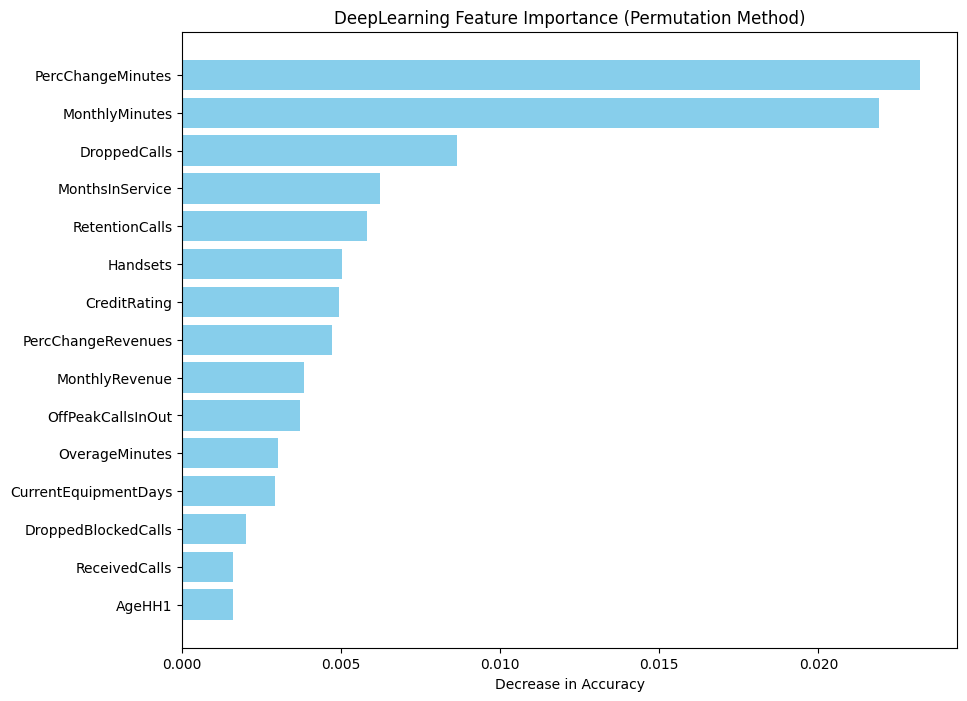

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_feature_importance(model, X_tensor, y_tensor, feature_names):
    model.eval()
    
    # 1. 원본 데이터로 기준 성능(Accuracy) 계산
    with torch.no_grad():
        outputs = model(X_tensor)
        base_acc = (outputs.argmax(dim=1) == y_tensor).float().mean().item()
    
    importances = []
    
    # 2. 각 피처를 하나씩 섞어보며 성능 변화 관찰
    for i in range(X_tensor.shape[1]):
        temp_X = X_tensor.clone()
        
        # i번째 컬럼의 데이터만 무작위로 섞기 (Permutation)
        perm_idx = torch.randperm(temp_X.size(0))
        temp_X[:, i] = temp_X[perm_idx, i]
        
        with torch.no_grad():
            shuffled_out = model(temp_X)
            shuffled_acc = (shuffled_out.argmax(dim=1) == y_tensor).float().mean().item()
        
        # 성능이 얼마나 감소했는지 기록
        importances.append(base_acc - shuffled_acc)
    
    # 3. 결과 시각화
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values(by='importance', ascending=False).head(15) # 상위 15개

    plt.figure(figsize=(10, 8))
    plt.barh(fi_df['feature'], fi_df['importance'], color='skyblue')
    plt.gca().invert_yaxis() # 높은 중요도가 위로 오게
    plt.title("DeepLearning Feature Importance (Permutation Method)")
    plt.xlabel("Decrease in Accuracy")

    plt.savefig(BASE_DIR + '/asset/graph/MLP_FeatureImportance.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행 (X_val_tensor와 원본 X의 컬럼명을 넣어주세요)
plot_feature_importance(model, X_val_tensor, y_val_tensor, X.columns)

### Confusion Matrix

In [90]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import torch

# 1. 모델을 평가 모드로 전환
model.eval()

all_preds = []
all_labels = []

# 2. 검증 데이터를 통해 예측값 모으기
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        # 가장 높은 확률을 가진 인덱스를 예측값으로 선택
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 정확도(Accuracy) 계산
acc = accuracy_score(all_labels, all_preds)

print("              Classification Report")

# 클래스 이름을 명시하면 더 보기 좋습니다 (0: 유지, 1: 이탈)
print(classification_report(all_labels, all_preds, target_names=['Stay (0)', 'Churn (1)']))

              Classification Report
              precision    recall  f1-score   support

    Stay (0)       0.73      0.96      0.83      7112
   Churn (1)       0.52      0.09      0.16      2844

    accuracy                           0.72      9956
   macro avg       0.62      0.53      0.49      9956
weighted avg       0.67      0.72      0.64      9956



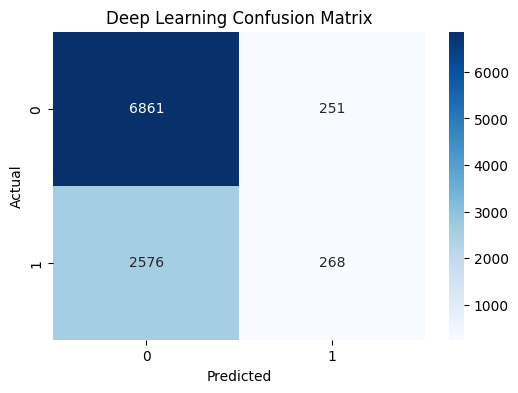

In [91]:
# 5. Confusion Matrix 출력
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Deep Learning Confusion Matrix')

plt.savefig(BASE_DIR + '/asset/graph/MLP_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()



### ROC/AUC

0.6501211428872024


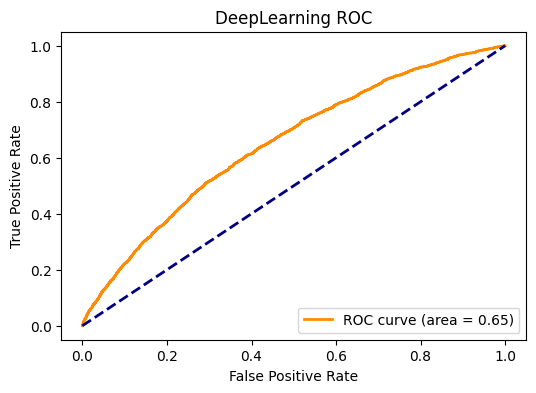

In [92]:
# 6. ROC-AUC 계산
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DeepLearning ROC')
plt.legend(loc="lower right")

plt.savefig(BASE_DIR + '/asset/graph/MLP_ROC_curve.png', dpi=300, bbox_inches='tight')

print(roc_auc)
plt.show()

### 모델 저장

In [96]:
# 모델 저장
torch.save(model.state_dict(), 'mlp_state.pt')

In [94]:
import torch

# 1. 평가(추론) 모드 전환
model.eval()

# 2. 내 모델의 입력 피처 수 확인 (아까 설정한 INPUT_SIZE)
# 만약 INPUT_SIZE 변수가 기억 안 난다면 X_train.shape[1]을 직접 써주세요.
num_features = X_train.shape[1] 

# 3. 더미 입력 생성 (배치 사이즈는 상관없지만, 피처 수는 정확해야 합니다!)
# (1, num_features) 형태로 만들어 1개 데이터를 넣었을 때를 가정합니다.
dummy_input = torch.randn(1, num_features).to(next(model.parameters()).device)


# 4. PyTorch 모델을 ONNX 포맷으로 저장
torch.onnx.export(
    model,
    dummy_input,                # 모델이 기대하는 입력 데이터의 형태
    'mlp.onnx',        # 저장 경로 및 파일명
    export_params=True,         # 가중치값도 함께 저장 (필수!)
    opset_version=11,           # 호환성이 가장 좋은 버전
    do_constant_folding=True,   # 최적화 기법 적용
    input_names=['input'],      # 입력 레이어 이름
    output_names=['output'],    # 출력 레이어 이름
    # 실무 꿀팁: 나중에 배치 사이즈를 마음대로 넣고 싶을 때 설정
    # dynamic_axes={
    #     'input': {0: 'batch_size'}, 
    #     'output': {0: 'batch_size'}
    # }
)

print("✅ 모델이 mlp.onnx로 성공적으로 저장되었습니다!")

✅ 모델이 mlp.onnx로 성공적으로 저장되었습니다!
